# Know your data: datasets and synthetic processes

Start here. Before resampling a series you should know its statistical regime,
because that regime is what decides which bootstrap method is valid. Here we load every real dataset and
build every synthetic process used elsewhere in the suite, plot each one, name
the regime it demonstrates, and preview what `diagnose` says about it.

The real datasets come from `sktime` and `statsmodels`, both pulled in by the
`tsbootstrap[examples]` extra. The synthetic processes are defined inline with
nothing but numpy, so the volatility-clustering example needs no financial-data
dependency at all.


In [1]:
# On Colab or Binder, install tsbootstrap first (skipped if already present):
try:
    import tsbootstrap  # noqa: F401
except ImportError:
    %pip install -q "tsbootstrap[examples]"

## Imports

A few imports shared by every cell below.

In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np

warnings.filterwarnings("ignore")  # keep dataset loaders and ADF tests quiet
rng = np.random.default_rng(0)

## Bundled real datasets

Six real series, each a different regime. We plot every one and note in a single
line what makes it interesting for resampling.


### Airline passengers (monthly)

This series has a trend and strong multiplicative seasonality. The dependence
is structured, not random, so plain i.i.d. resampling would destroy it.


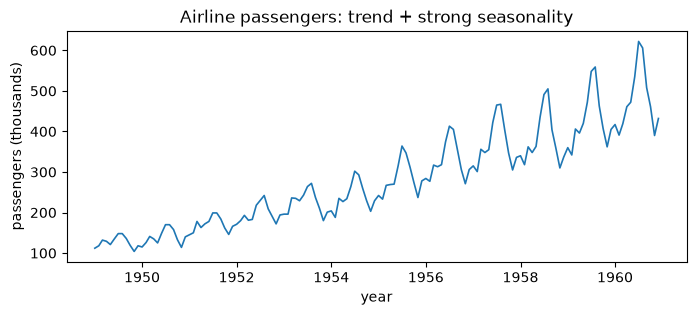

In [3]:
from sktime.datasets import load_airline

airline = load_airline()  # pandas Series, PeriodIndex (monthly)
y = airline.to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(airline.index.to_timestamp(), y, color="tab:blue", lw=1.2)
ax.set_title("Airline passengers: trend + strong seasonality")
ax.set_xlabel("year")
ax.set_ylabel("passengers (thousands)")
plt.show()

### Canadian lynx (annual)

Aperiodic cyclical. The boom-and-bust cycle is real but its period wanders, so it
is not clean seasonality.


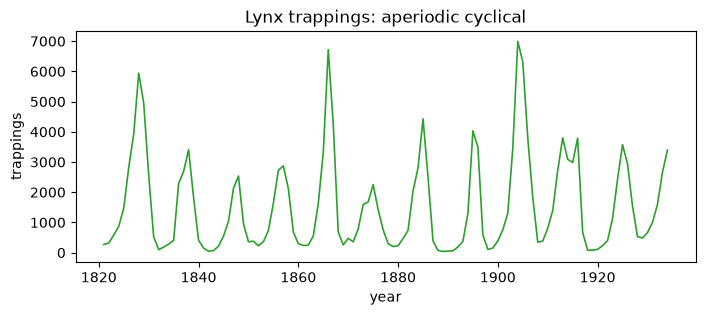

In [4]:
from sktime.datasets import load_lynx

lynx = load_lynx()  # pandas Series, PeriodIndex (annual)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(lynx.index.year, lynx.to_numpy(dtype=float), color="tab:green", lw=1.2)
ax.set_title("Lynx trappings: aperiodic cyclical")
ax.set_xlabel("year")
ax.set_ylabel("trappings")
plt.show()

### Shampoo sales (monthly)

Short series with an upward trend that sits near a unit root. Only 36 points, so
it also stresses methods that assume plenty of data.


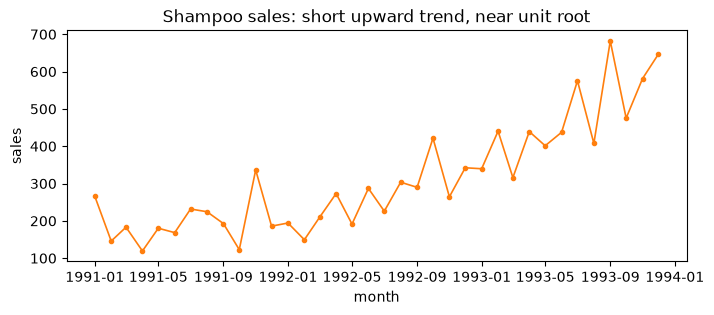

In [5]:
from sktime.datasets import load_shampoo_sales

shampoo = load_shampoo_sales()  # pandas Series, PeriodIndex (monthly), n=36

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(
    shampoo.index.to_timestamp(),
    shampoo.to_numpy(dtype=float),
    color="tab:orange",
    lw=1.2,
    marker="o",
    ms=3,
)
ax.set_title("Shampoo sales: short upward trend, near unit root")
ax.set_xlabel("month")
ax.set_ylabel("sales")
plt.show()

### Nile river flow (annual)

A unit-root level with a well-known changepoint near 1898 (construction of the
Aswan dam reduced the flow). A clear case where the series is non-stationary.


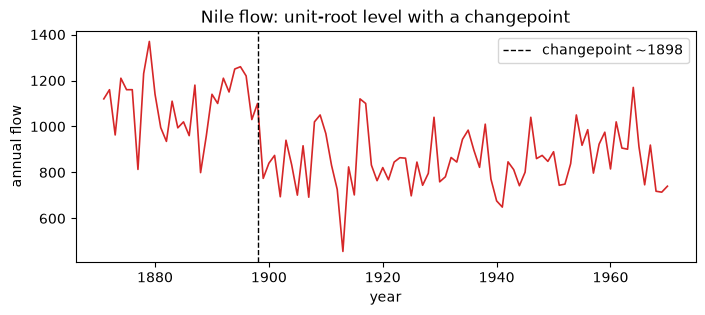

In [6]:
from statsmodels.datasets import nile

nile_df = nile.load_pandas().data  # columns: year, volume
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(nile_df["year"], nile_df["volume"], color="tab:red", lw=1.2)
ax.axvline(1898, color="black", ls="--", lw=1.0, label="changepoint ~1898")
ax.set_title("Nile flow: unit-root level with a changepoint")
ax.set_xlabel("year")
ax.set_ylabel("annual flow")
ax.legend()
plt.show()

### Sunspots (yearly)

Quasi-periodic, with a roughly 11 year solar cycle whose amplitude varies. A good
test for methods that must preserve a dominant but inexact cycle.


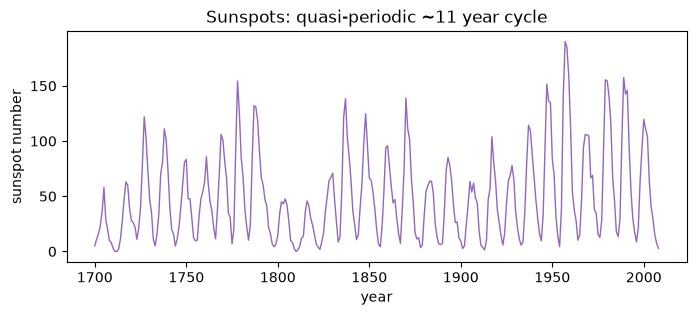

In [7]:
from statsmodels.datasets import sunspots

sun_df = sunspots.load_pandas().data  # columns: YEAR, SUNACTIVITY
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(sun_df["YEAR"], sun_df["SUNACTIVITY"], color="tab:purple", lw=1.0)
ax.set_title("Sunspots: quasi-periodic ~11 year cycle")
ax.set_xlabel("year")
ax.set_ylabel("sunspot number")
plt.show()

### US macro indicators (quarterly, multivariate)

Three cross-correlated series: real GDP, real consumption, and the CPI. The
cross-series dependence is the point: this is the regime where a VAR model, which
captures how the series move together, is the natural choice.


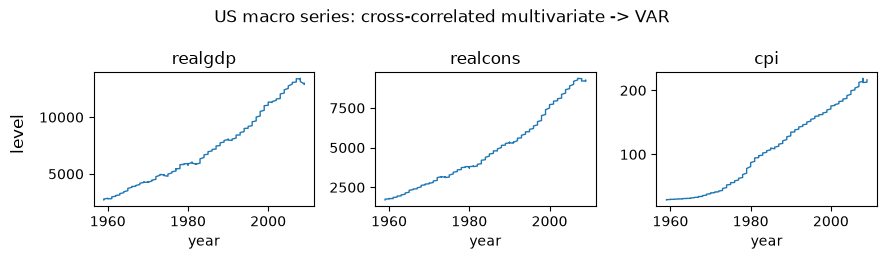

In [8]:
from statsmodels.datasets import macrodata

macro_df = macrodata.load_pandas().data
cols = ["realgdp", "realcons", "cpi"]
macro = macro_df[cols].to_numpy(dtype=float)  # shape (203, 3)

fig, axes = plt.subplots(1, 3, figsize=(9, 2.6), sharex=True)
for ax, col in zip(axes, cols):
    ax.plot(macro_df["year"], macro_df[col], lw=1.0)
    ax.set_title(col)
    ax.set_xlabel("year")
fig.supylabel("level")
fig.suptitle("US macro series: cross-correlated multivariate -> VAR")
fig.tight_layout()
plt.show()

## Synthetic data-generating processes

Now the controlled cases. Because we define each process, we know its true
properties exactly, which makes them ideal for checking that a method recovers
what it should. Everything below is plain numpy.


### AR(1), phi = 0.5: known theoretical ACF

For a stationary AR(1) the autocorrelation at lag k is exactly rho_k = phi^k. We
overlay the sample ACF against that closed form to confirm the match.


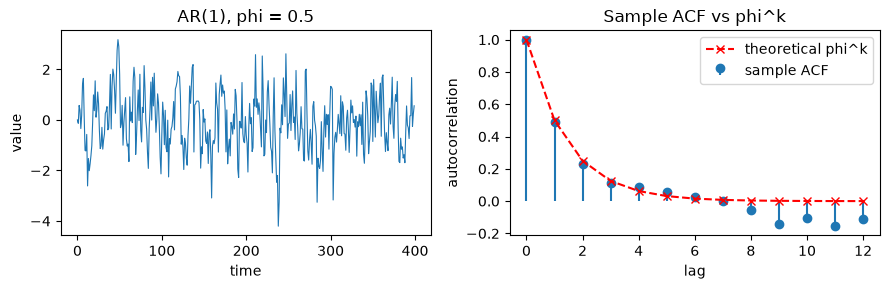

In [9]:
def ar1(n, phi, rng):
    x = np.zeros(n)
    e = rng.standard_normal(n)
    for t in range(1, n):
        x[t] = phi * x[t - 1] + e[t]
    return x


def sample_acf(x, max_lag):
    x = x - x.mean()
    denom = np.dot(x, x)
    return np.array(
        [np.dot(x[: -k or None], x[k:]) / denom if k else 1.0 for k in range(max_lag + 1)]
    )


phi = 0.5
x_ar1 = ar1(400, phi, rng)
max_lag = 12
acf_hat = sample_acf(x_ar1, max_lag)
acf_true = phi ** np.arange(max_lag + 1)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 3))
a1.plot(x_ar1, color="tab:blue", lw=0.8)
a1.set_title("AR(1), phi = 0.5")
a1.set_xlabel("time")
a1.set_ylabel("value")
lags = np.arange(max_lag + 1)
a2.stem(lags, acf_hat, linefmt="tab:blue", markerfmt="o", basefmt=" ", label="sample ACF")
a2.plot(lags, acf_true, "r--", marker="x", label="theoretical phi^k")
a2.set_title("Sample ACF vs phi^k")
a2.set_xlabel("lag")
a2.set_ylabel("autocorrelation")
a2.legend()
fig.tight_layout()
plt.show()

### AR(2)

A second-order process can produce pseudo-cyclical behavior from pure linear
dynamics, with no seasonal term involved.


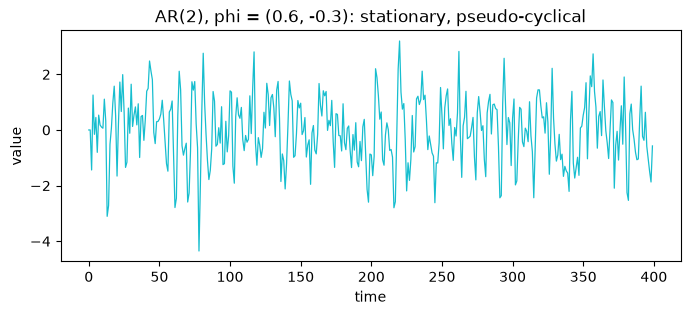

In [10]:
def ar2(n, phi1, phi2, rng):
    x = np.zeros(n)
    e = rng.standard_normal(n)
    for t in range(2, n):
        x[t] = phi1 * x[t - 1] + phi2 * x[t - 2] + e[t]
    return x


x_ar2 = ar2(400, 0.6, -0.3, rng)
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(x_ar2, color="tab:cyan", lw=0.9)
ax.set_title("AR(2), phi = (0.6, -0.3): stationary, pseudo-cyclical")
ax.set_xlabel("time")
ax.set_ylabel("value")
plt.show()

### Seasonal plus trend

A deterministic linear trend with a sine seasonal component and additive noise.
The non-stationary mean comes entirely from the trend term.


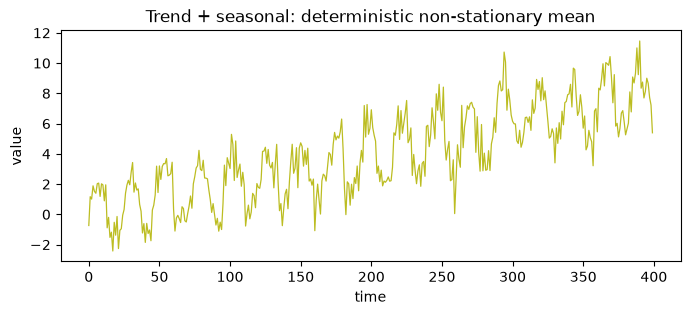

In [11]:
n = 400
t = np.arange(n)
period = 24
x_seas = 0.02 * t + 2.0 * np.sin(2 * np.pi * t / period) + rng.standard_normal(n)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t, x_seas, color="tab:olive", lw=0.9)
ax.set_title("Trend + seasonal: deterministic non-stationary mean")
ax.set_xlabel("time")
ax.set_ylabel("value")
plt.show()

### Random walk: unit root

This is the textbook non-stationary process. Its variance grows without bound,
so any method that assumes a fixed level will misrepresent it.


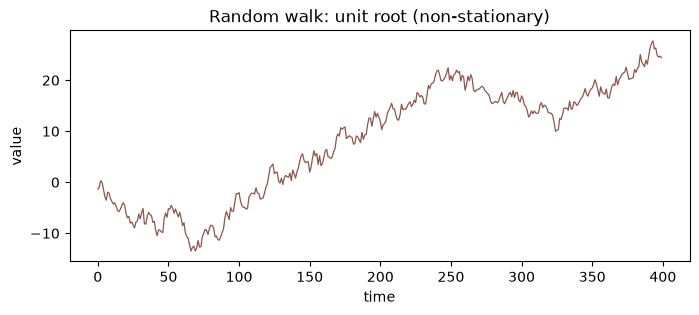

In [12]:
x_rw = np.cumsum(rng.standard_normal(400))

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(x_rw, color="tab:brown", lw=0.9)
ax.set_title("Random walk: unit root (non-stationary)")
ax.set_xlabel("time")
ax.set_ylabel("value")
plt.show()

### GARCH(1,1): volatility clustering, no financial data

This is how the suite demonstrates volatility clustering without any market data.
We simulate the conditional variance recursion
`sigma2_t = omega + alpha * e_{t-1}^2 + beta * sigma2_{t-1}` and draw
`e_t = sigma_t * z_t`. Plotting the squared series makes the clustering obvious:
large moves bunch together in time.


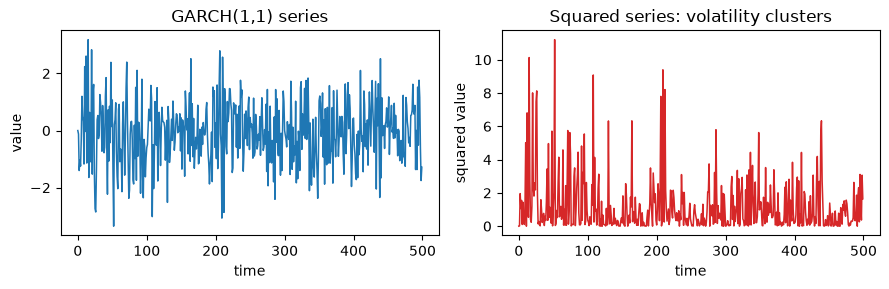

In [13]:
def garch11(n, omega, alpha, beta, rng):
    e = np.zeros(n)
    sigma2 = np.empty(n)
    sigma2[0] = omega / (1 - alpha - beta)  # unconditional variance
    z = rng.standard_normal(n)
    for t in range(1, n):
        sigma2[t] = omega + alpha * e[t - 1] ** 2 + beta * sigma2[t - 1]
        e[t] = np.sqrt(sigma2[t]) * z[t]
    return e


x_garch = garch11(500, omega=0.05, alpha=0.1, beta=0.85, rng=rng)

fig, (g1, g2) = plt.subplots(1, 2, figsize=(9, 3))
g1.plot(x_garch, color="tab:blue", lw=1.1)
g1.set_title("GARCH(1,1) series")
g1.set_xlabel("time")
g1.set_ylabel("value")
g2.plot(x_garch**2, color="tab:red", lw=1.1)
g2.set_title("Squared series: volatility clusters")
g2.set_xlabel("time")
g2.set_ylabel("squared value")
fig.tight_layout()
plt.show()

### Bivariate VAR(1): cross-correlated 2D

Two series whose dynamics are coupled through a coefficient matrix. The off
diagonal terms make each series depend on the other's past, which is exactly the
structure a VAR-based bootstrap is built to preserve.


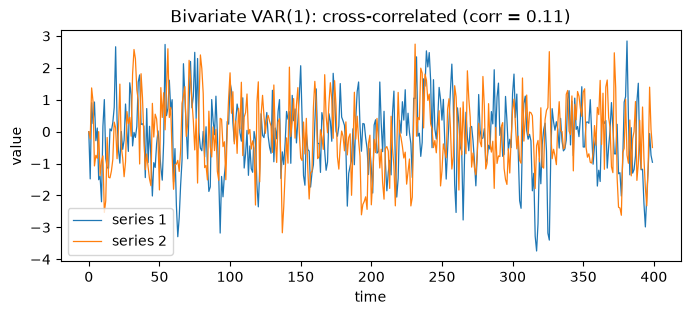

In [14]:
def var1(n, A, rng):
    d = A.shape[0]
    X = np.zeros((n, d))
    E = rng.standard_normal((n, d))
    for t in range(1, n):
        X[t] = A @ X[t - 1] + E[t]
    return X


A = np.array([[0.5, 0.2], [0.1, 0.4]])
X_var = var1(400, A, rng)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(X_var[:, 0], color="tab:blue", lw=0.9, label="series 1")
ax.plot(X_var[:, 1], color="tab:orange", lw=0.9, label="series 2")
corr = np.corrcoef(X_var[:, 0], X_var[:, 1])[0, 1]
ax.set_title(f"Bivariate VAR(1): cross-correlated (corr = {corr:.2f})")
ax.set_xlabel("time")
ax.set_ylabel("value")
ax.legend()
plt.show()

## A diagnose() preview

`diagnose` measures serial dependence and stationarity, then maps what it sees to
method specifications. It returns a `Diagnosis` dataclass; the two fields we read
here are `recommended_methods` and `notes`. We run it across a representative mix
of the series above.

`diagnose` reports what it measures and maps it to candidate methods. The
decision-guide notebook works through when each recommended method is the right choice.


In [15]:
from tsbootstrap import diagnose

probes = {
    "AR(1) stationary": x_ar1,
    "random walk": x_rw,
    "airline (trend+seasonal)": y,
    "GARCH(1,1)": x_garch,
    "VAR(1) bivariate": X_var,
}

for name, series in probes.items():
    d = diagnose(series)
    print(f"{name}:")
    print(f"  recommended_methods: {d.recommended_methods}")
    for note in d.notes:
        print(f"  note: {note}")
    print()

AR(1) stationary:
  recommended_methods: ('StationaryBlock', 'MovingBlock', 'SieveAR')
  note: Serial dependence present (lag-1 autocorrelation 0.49): use a block method or the sieve.
  note: Suggested automatic block length (Politis-White): 9.

random walk:
  recommended_methods: ('ResidualBootstrap(model=ARIMA(...))', 'SieveAR')
  note: Series looks non-stationary (unit root): difference it via ARIMA, or use the sieve.

airline (trend+seasonal):
  recommended_methods: ('ResidualBootstrap(model=ARIMA(...))', 'SieveAR')
  note: Series looks non-stationary (unit root): difference it via ARIMA, or use the sieve.

GARCH(1,1):
  recommended_methods: ('IID', 'MovingBlock')
  note: Serial dependence is weak: i.i.d. resampling is acceptable; a block method is a safe default.

VAR(1) bivariate:
  recommended_methods: ('ResidualBootstrap(model=VAR(...))', 'StationaryBlock', 'MovingBlock', 'SieveAR')
  note: Serial dependence present (lag-1 autocorrelation 0.48): use a block method or the sieve.